# Data Exploration

**Course:** Computational Cognitive Science (Summer 2026)

**Project:** Delay Discounting Dataset (DD)

**Objective:** This notebook explores the delay discounting dataset, understand the structure, inspect the variables, and perform the preprocessing required before fitting the choice and reaction time models.

# 1. Import Libraries

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path
import sys

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Load Dataset

In [3]:
from src.data_loader import load_all_participants

In [4]:
from src.config import DATA_DIR
participants = load_all_participants(DATA_DIR)

In [5]:
print(f"Number of participants: {len(participants)}")

Number of participants: 99


In [6]:
train_trials = sum(len(p["train"]) for p in participants.values())
test_trials = sum(len(p["test"]) for p in participants.values())

print(f"Training trials: {train_trials}")
print(f"Testing trials: {test_trials}")

Training trials: 8920
Testing trials: 20070


In [7]:
participants[list(participants.keys())[0]]["train"].head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5


To better understand the dataset, we first inspect the training data from one participant. This provides an overview of the available variables and their format.

The following summary provides basic statistics describing the number of training and testing trials across all participants.

In [8]:
from src.utils import print_dataset_summary

summary_df = print_dataset_summary(participants)

       train_trials  test_trials
count     99.000000    99.000000
mean      90.101010   202.727273
std       10.050378    22.613351
min       80.000000   180.000000
25%       80.000000   180.000000
50%      100.000000   225.000000
75%      100.000000   225.000000
max      100.000000   225.000000


# 3. Dataset Overview

In [9]:
missing_rt = 0

for participant in participants.values():
    missing_rt += participant["train"]["RT"].isna().sum()
    missing_rt += participant["test"]["RT"].isna().sum()

print(f"Total missing RT values: {missing_rt}")

Total missing RT values: 93


In [10]:
choice_counts = {1: 0, 2: 0, 0: 0}
for participant in participants.values():
    for df in [participant["train"], participant["test"]]:

        counts = df["choice"].value_counts()

        for choice, count in counts.items():
            choice_counts[int(choice)] += count

print(choice_counts)

{1: 12840, 2: 16057, 0: 93}


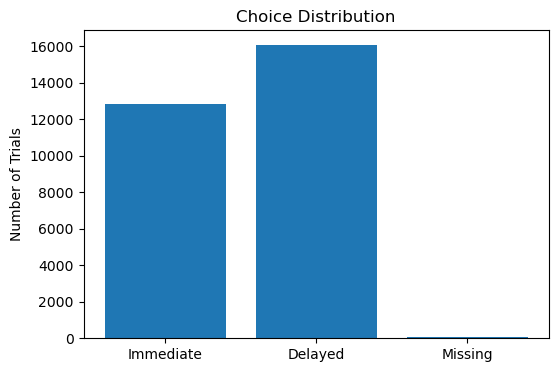

In [11]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Immediate", "Delayed", "Missing"],
    [
        choice_counts[1],
        choice_counts[2],
        choice_counts[0]
    ]
)
plt.title("Choice Distribution")
plt.ylabel("Number of Trials")
plt.show()

The above figure shows how often participants selected the immediate and delayed options across all trials.

In [12]:
all_rt = []
for participant in participants.values():
    for df in [participant["train"], participant["test"]]:
        all_rt.extend(df["RT"].dropna())

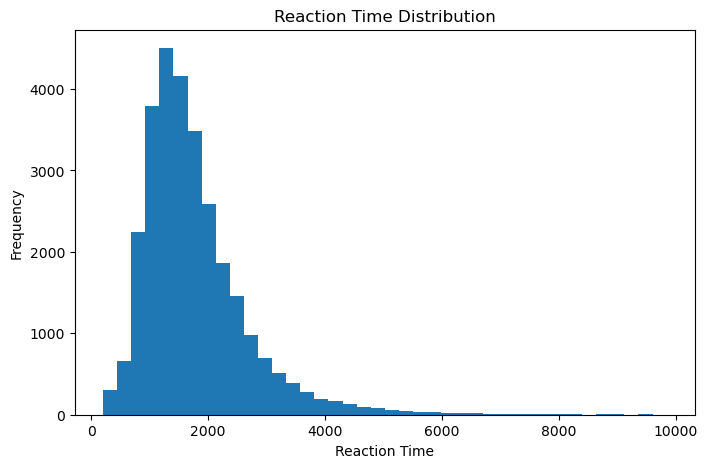

In [13]:
plt.figure(figsize=(8,5))
plt.hist(all_rt, bins=40)
plt.title("Reaction Time Distribution")
plt.xlabel("Reaction Time")
plt.ylabel("Frequency")
plt.show()

We inspect the distribution of reaction times to see the range of decision times and identify potential outliers.

The dataset contains both reward and loss conditions. Their frequencies are inspected below.

In [14]:
reward = 0
loss = 0

for participant in participants.values():
    for df in [participant["train"], participant["test"]]:
        reward += (df["condition"] == 1).sum()
        loss += (df["condition"] == 2).sum()

print(f"Reward trials: {reward}")
print(f"Loss trials: {loss}")

Reward trials: 28990
Loss trials: 0


# 4. Preprocessing

In [15]:
from src.preprocessing import get_split, combine_participants

In [16]:
train = get_split(participants, "train")
combined_train = combine_participants(train)
combined_train.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,participant
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,Sample1_07mpzgefw
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,Sample1_07mpzgefw
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,Sample1_07mpzgefw
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,Sample1_07mpzgefw
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,Sample1_07mpzgefw


In [17]:
combined_train.shape

(8920, 8)

In [18]:
from src.discounting import *

In [19]:
from src.discounting import add_subjective_values

participant = add_subjective_values(
    combined_train,
    k=0.01
)

participant.head()

,immOutcome,delOutcome,delay,choice,p_imm,condition,RT,participant,SV_immediate,SV_delayed,value_difference
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,Sample1_07mpzgefw,1.79,1.785714,-0.004286
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,Sample1_07mpzgefw,9.99,7.692308,-2.297692
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,Sample1_07mpzgefw,7.33,2.150538,-5.179462
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,Sample1_07mpzgefw,0.46,17.857143,17.397143
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,Sample1_07mpzgefw,0.91,26.315789,25.405789
